write a function that will take rows from user_table and loop over them to:
- create a piping_section class
- calculate all profiles
- calculate all heat rates per length
- prepare it all for final_prep function and units handling

after that clean the code, add missing description and change preparation functions and finalizing functions

I think I like to go with final table looking like this
start_len --- end_len --- start_temp --- end_temp --- start_surf_temp --- end_surf_temp --- heat per len to insulation --- conv heat --- rad heat --- total --- difference

or instead of start and end len it could be cumulative length only? or maybe a segment length only, and then i could provide user with "additional values" and give total length, time of residence, maybe some weighted averages for velocity (length weighted, cylindrical area weighted)

I was thinking also about dropping heat transfer coefficient for fluid to piping wall, as users might not know what to put there, and if volumetric flow rate is high enough the value is in hundreds of W/mK, the problem is that if I'd wanted to calculate it myself I'd need Re number, so I'd require viscosity from users, and I guess this would be easier for them to provide (but I know that when user have to leave one software to go to another to fetch a value there is additional degree of freedom to mess it up, I've seen it countless times), or I'd need na API to connect this to some database... I was thinking that I could take a lot of popular fluids and fit one universal viscosity function to it. Making it only temperature dependent could render a lot of variability, but I could make it both temperature and molecular mass dependent, this could render interesting results, and then users would only specify the molecular mass and the rest would be handled under the hood. It would be much easier for users to provide M instead of heat transfer coeff, given that a lot of them might now even understand of what they are inputing. Of course, if insulation is thicker than 0.1 inch, this heat transfer coeff above like 5 BTU/ft2.h.F will not make any difference, but I've seen enought to know that if someone can put there a wrong value they will.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

- i dont need cumulative length to be honest
- i dont need to append zeros on top of the prepared table

  here is how it can look like

In [2]:
# USER TABLE EXAMPLE
user_array = np.array([
    [4, 3.8, 0.5, 876],
    [3, 2.8, 0.5, 2727],
    [2, 1.8, 0.5, 208]
])

user_table_raw = pd.DataFrame(user_array, columns=['pipe_outer_diameter', 'pipe_inner_diameter', 'insulation_thickness', 'segment_length'])

# this is no longer needed
# 
# user_table_raw['cumulative_length'] = user_table_raw['segment_length'].cumsum()
# user_table = pd.concat([user_table_raw.iloc[0, :].to_frame().T, user_table_raw], ignore_index=True)
# user_table.iloc[0, -2:] = 1e-6

# PROPERTIES TABLE EXAMPLE
properties_table = pd.Series([188.6, 68, 60, 9.7, 0.025, 190, 60, 1, 1], index=['inlet_temperature', 'ambient_temperature', 'h_fluid_to_pipe', 'k_pipe', 'k_insulation', 'volumetric_flow_rate', 'density', 'specific_heat_capacity', 'emissivity'])

In [3]:
user_table_raw

,pipe_outer_diameter,pipe_inner_diameter,insulation_thickness,segment_length
0,4.0,3.8,0.5,876.0
1,3.0,2.8,0.5,2727.0
2,2.0,1.8,0.5,208.0


In [37]:
class Piping_Section:

    def __init__(
        self,
        outer_diameter,
        inner_diameter,
        insulation_thickness,
        segment_length,
        start_length,
        inlet_temperature,
        ambient_temperature,
        h_fluid_to_pipe, 
        k_pipe, 
        k_insulation,
        density,
        volumetric_flow_rate,
        specific_heat_capacity,
        h_combined_func
    ):

        # piping geometry
        self.outer_diameter = outer_diameter
        self.inner_diameter = inner_diameter
        self.insulation_thickness = insulation_thickness
        self.segment_length = segment_length
        self.start_length = start_length
        self.total_diameter = self.outer_diameter + 2 * self.insulation_thickness
        self.end_length = self.start_length + self.segment_length
        
        # piping thermal properties
        self.h_fluid_to_pipe = h_fluid_to_pipe
        self.k_pipe = k_pipe
        self.k_insulation = k_insulation

        # fluid properties
        self.inlet_temperature = inlet_temperature
        self.ambient_temperature = ambient_temperature
        self.density = density
        self.volumetric_flow_rate = volumetric_flow_rate
        self.specific_heat_capacity = specific_heat_capacity
        
        # 1LPM = 0.0353147 ft3/min * 60 min / 1 h
        self.mass_flow_rate = self.density * self.volumetric_flow_rate * 0.0353147 * 60 # lbm/h

        # heat transfer coefficient functoin
        self.h_comb = h_combined_func

    def K(
        self,
        h_combined
    ):
    
        '''
        Calculate combined thermal conductivity.
    
        Parameters
        ----------
        h_combined: float, array_like
            Combined surface heat transfer coeff (convection + radiation effect) [BTU/ft2.h.F]
    
        Returns
        -------
        _K: float, array_like
            Combined thermal conductivity [BTU/ft.h.F]
        '''

        _R = (12 * 2) / (self.h_fluid_to_pipe * self.inner_diameter) +\
             np.log( self.outer_diameter / self.inner_diameter ) / self.k_pipe +\
             np.log( self.total_diameter / self.outer_diameter ) / self.k_insulation +\
             (12 * 2) / (h_combined * self.total_diameter)
    
        self.K_combined = 1 / _R

        return self.K_combined

    def T(
        self,
        length, 
        h_combined
    ):
    
        '''
        Calculate fluid temperature at provided length and combined heat transfer coefficient.
    
        Parameters
        ----------
        length: float, array_like
            Length at which temperature is to be calculated [ft]
        h_combined_surface: float, array_like
            Combined heat transfer coefficient at the insulation-air interface [BTU/ft2.h.F]
    
        Returns
        -------
        T_at_length: float, array_like
            Temperature calculated at provided length [F]
        '''
    
        exponential_part = np.exp(
            -2 * np.pi * self.K(h_combined) * length / ( self.mass_flow_rate * self.specific_heat_capacity )
        )
    
        T_at_length = self.ambient_temperature + ( self.inlet_temperature - self.ambient_temperature ) * exponential_part
    
        self.fluid_temperature = T_at_length

        return self.fluid_temperature

    def calculate_heat_per_length(self, k, T_2, T_1):
        return 2 * np.pi * k * (T_2 - T_1)

    # using one function we can calculate every single one of necessary heat rates
    # q_to_pipe_insulation = self.calculate_heat_per_length(K(10000), fluid_temp, surface_temp)
    # q_through_total = self.calculate_heat_per_length(K(h_comb), fluid_temp, ambient_temp)
    # q_combined = self.calculate_heat_per_length([h_rad, h_conv] * total_diameter / 2, surface_temp, ambient_temp)

    
    def loss_function(self, surface_temperature, length=None):
        h_comb = self.h_comb(surface_temperature).sum(1)
        self.T(length, h_comb)
        loss = (
            self.calculate_heat_per_length(self.K(10000), self.fluid_temperature, surface_temperature) -\
            self.calculate_heat_per_length(self.K(h_comb), self.fluid_temperature, self.ambient_temperature)
        ) ** 2
        return loss

    def loss_function2(self, surface_temperature, length=None):
        h_comb = self.h_comb(surface_temperature).sum(1)
        self.T(length, h_comb)
        loss = (
            self.calculate_heat_per_length(self.K(10000), self.fluid_temperature, surface_temperature) -\
            self.calculate_heat_per_length(h_comb * self.total_diameter / 24, surface_temperature, self.ambient_temperature)
        ) ** 2
        return loss
        
    def loss_function3(self, surface_temperature, length=None):
        h_comb = self.h_comb(surface_temperature).sum(1)
        self.T(length, h_comb)
        loss = (
            self.calculate_heat_per_length(h_comb * self.total_diameter / 24, surface_temperature, self.ambient_temperature) -\
            self.calculate_heat_per_length(self.K(h_comb), self.fluid_temperature, self.ambient_temperature)
        ) ** 2
        return loss

    def find_surface_temp(self, length):

        self.minim = minimize(
            self.loss_function,
            (self.inlet_temperature + self.ambient_temperature) / 2,
            args=(length)
        )

        return self.minim.x

    def temperature_profile(self, n=2):

        temp_profile = []
        surf_temp_profile = []
        h_comb_profile = []
        segment_length_profile = []
        for _l in np.linspace(0, self.segment_length, n):
            
            _T_surf_l = self.find_surface_temp(_l)
            _h_comb_vec_l = self.h_comb(_T_surf_l).flatten()
            _T_l = self.T(_l, _h_comb_vec_l.sum())

            temp_profile.append(_T_l)
            surf_temp_profile.append(_T_surf_l)
            h_comb_profile.append(_h_comb_vec_l)
            segment_length_profile.append(_l)

        _result_df = pd.DataFrame(
            np.c_[segment_length_profile, temp_profile, surf_temp_profile, h_comb_profile],
            columns=["length", "temp", "surf_temp", "h_rad", "h_conv"]
        )

        return _result_df

In [62]:
ps1 = Piping_Section(4, 3.8, 0.0, 87600, 0, 188.6, 68, 60, 9.75, 0.025, 60, 190, 1, a.h_combined)

In [63]:
ps1.temperature_profile()

,length,temp,surf_temp,h_rad,h_conv
0,0.0,188.600000,183.420645,1.385387,1.036927
1,87600.0,68.997215,68.973895,1.007733,0.285011


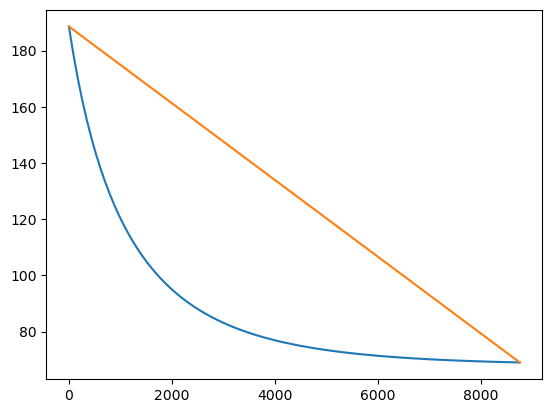

In [64]:
plt.plot(np.linspace(0, 8760, 100), ps1.temperature_profile(100).temp)
plt.plot([0, 8760], ps1.temperature_profile().temp)

In [13]:
a.h_combined(100)

array([[1.10011526, 0.74034565]])

In [14]:
ps1.loss_function(95.52, length=0)

array([8.62611079e-06])

In [15]:
ps1.find_surface_temp(ps1.end_length)

array([95.04249099])

In [16]:
ps1.h_comb(100)

array([[1.10011526, 0.74034565]])

In [17]:
ps1 = Piping_Section(4, 3.8, 0.5, 876, 0, 188.6, 68, 60, 9.75, 0.025, 60, 190, 1, a.h_combined)
ps2 = Piping_Section(3, 2.8, 0.5, 2727, ps1.end_length, ps1.T(ps1.segment_length, 10000), 68, 60, 9.75, 0.025, 60, 190, 1, a.h_combined)
ps3 = Piping_Section(2, 1.8, 0.5, 1500, ps2.end_length, ps2.T(ps2.segment_length, 10000), 68, 60, 9.75, 0.025, 60, 190, 1, a.h_combined)

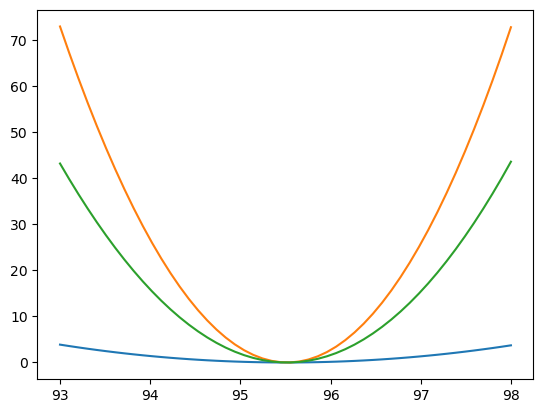

In [18]:
plt.plot(np.linspace(93, 98), ps1.loss_function(np.linspace(93, 98), 0))
plt.plot(np.linspace(93, 98), ps1.loss_function2(np.linspace(93, 98), 0))
plt.plot(np.linspace(93, 98), ps1.loss_function3(np.linspace(93, 98), 0))

In [19]:
T1 = ps1.T(np.linspace(0, ps1.segment_length), 10000)
T2 = ps2.T(np.linspace(0, ps2.segment_length), 10000)
T3 = ps3.T(np.linspace(0, ps3.segment_length), 10000)

In [20]:
L = np.array([np.linspace(c.start_length, c.end_length) for c in [ps1, ps2, ps3]]).T
T = np.array([T_L for T_L in [T1, T2, T3]]).T

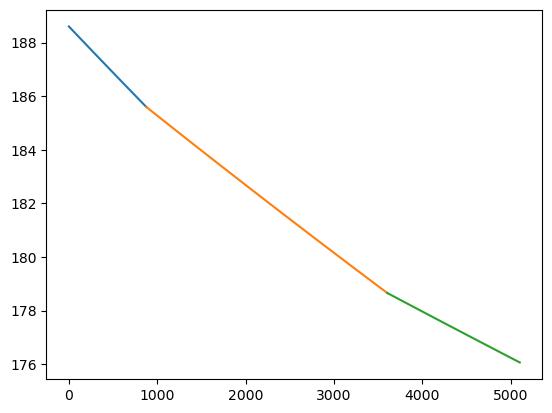

In [21]:
plt.plot(L, T)

In [6]:
class Air:

    def __init__(
        self,
        outer_diameter,
        insulation_thickness,
        ambient_temperature,
        emissivity
    ):

        self.total_diameter = outer_diameter + 2 * insulation_thickness
        self.ambient_temperature = ambient_temperature
        self.emissivity = emissivity
        

    def cp(
        self,
        ref_temperature
    ):

        '''
        Calculate specific heat capacity of air at reference temperature, which is film temperature of air around piping.
        Model is taken from Cengel, and is fitted to a range 273K - 1800K. Below 273K cp is equal to cp at 273K and above 
        1800K cp is equal to cp at 1800K.
    
        Parameters
        ----------
        ref_temperature: float, array_like
            Reference temperature at insulation-air interface [K]
    
        Returns
        -------
        _cp: float, array_like
            Specific heat capacity [kJ/kg.K]
        '''        
        
        # all constants here come from "Thermodynamics: An Engineering Approach" by Y. Cengel
        _cp_f = lambda ref_temperature: (28.11 + 0.1967e-2 * ref_temperature + 0.4802e-5 * ref_temperature ** 2 - 1.966e-9 * ref_temperature ** 3) / 28.96
        
        # going with np.array below assures that even when ref_temp is int all calculations carry on
        _cp = np.array(_cp_f(ref_temperature))
        _cp[ref_temperature < 273] = _cp_f(273)
        _cp[ref_temperature > 1800] = _cp_f(1800)
        return _cp

    def u(
        self,
        ref_temperature
    ):
    
        '''
        Calculate kinematic viscosity of air at reference temperature, which is film temperature of air around piping.
    
        Parameters
        ----------
        ref_temperature: float, array_like
            Reference temperature at insulation-air interface [K]
    
        Returns
        -------
        _u: float, array_like
            Kinematic viscosity [Pa*s]
        '''
    
        # Sutherland's Law
        _u = 1.458e-6 * ref_temperature ** 1.5 / (ref_temperature + 110.4)
        return _u
    
    def Ra(
        self,
        ambient_temperature,
        surface_temperature,
    ):
    
        '''
        Calculate Rayleigh number of air at film temperature for horizontal cylindrical body. 
        It is assummed that Pr=0.72 for air in all temperature range.
    
        Parameters
        ----------
        surface_temperature: float, array_like
            Insulation surface temperature [K]
        ambient_temperature: float
            Ambient temperature around piping [K]
    
        Returns
        -------
        _Ra: float, array_like
            Rayleigh number.
        '''

        film_temperature = (surface_temperature + ambient_temperature) / 2
    
        # Pr = 0.72 -> mean value for air on range from 220K to 2200K
        # g = 9.81 -> gravitational acceleration
        # P / R = 101.325 / 0.287 -> atmospheric pressure by gas constant for air
        # 0.0254 -> conversion from inch to meter
        _Ra = 0.72 * 9.81 * (101.325 / 0.287) ** 2 *\
            np.abs(surface_temperature - ambient_temperature) / (film_temperature ** 3 * self.u(film_temperature) ** 2) *\
            (self.total_diameter * 0.0254) ** 3
        
        return _Ra
    
    def h_combined(
        self,
        surface_temperature
    ):
    
        '''
        Calculate combined heat transfer coefficient at insulation-air interface.
        Radiation heat transfer coeff. is in its typical form.
        Convective heat transfer is based on Churchill and Chu correlation formula.
    
        Parameters
        ----------
        surface_temperature: float, array_like
            Insulation surface temperature [F]
    
        Returns
        -------
        _h_comb_vec: array_like
            Array with heat transfer coefficients of radiative and convective effects.
        '''
    
        surface_temperature_R = surface_temperature + 459.67
        ambient_temperature_R = self.ambient_temperature + 459.67
    
        # 1.71E-9 -> Stefan-Boltzmann constant
        h_rad = self.emissivity * 1.71E-9 *\
                (surface_temperature_R ** 2 + ambient_temperature_R ** 2) *\
                (surface_temperature_R + ambient_temperature_R)
    
        surface_temperature_K = surface_temperature_R * 5/9
        ambient_temperature_K = ambient_temperature_R * 5/9
        film_temperature_K = (surface_temperature_K + ambient_temperature_K) / 2
    
        # 0.1762280394 -> conversion from W/m.K to BTU/ft.h.F
        # 1000 -> conversion from kW to W
        # Pr = 0.72 -> mean value for air on range from 220K to 2200K
        # 0.6 + 0.387 / 1.20326 -> constants from Churchill and Chu correlation assuming Pr=0.72
        # 0.0254 -> conversion from inch to meters
        h_conv = 0.1762280394 * 1000 / 0.72 *\
                 (0.6 + 0.387 / 1.20326 * self.Ra(surface_temperature_K, ambient_temperature_K) ** (1/6)) ** 2 *\
                 self.u(film_temperature_K) * self.cp(film_temperature_K) / (self.total_diameter * 0.0254)
    
        _h_comb_vec = np.c_[h_rad, h_conv]
    
        return _h_comb_vec

In [7]:
a = Air(4, 0.5, 68, 1)

In [8]:
a.h_combined(100)

array([[1.10011526, 0.74034565]])

In [261]:
a.h_combined(np.linspace(10, 100))

array([[0.8510638 , 0.92075416],
       [0.85558478, 0.91117369],
       [0.86012816, 0.90141846],
       [0.86469402, 0.89147762],
       [0.86928242, 0.88133931],
       [0.87389341, 0.87099044],
       [0.87852706, 0.86041661],
       [0.88318344, 0.84960186],
       [0.88786261, 0.83852845],
       [0.89256464, 0.82717656],
       [0.89728958, 0.81552396],
       [0.9020375 , 0.8035456 ],
       [0.90680847, 0.79121305],
       [0.91160254, 0.7784939 ],
       [0.91641979, 0.76535089],
       [0.92126027, 0.75174093],
       [0.92612405, 0.73761373],
       [0.93101119, 0.72291002],
       [0.93592175, 0.70755926],
       [0.94085581, 0.69147647],
       [0.94581342, 0.67455777],
       [0.95079464, 0.65667422],
       [0.95579954, 0.63766263],
       [0.96082819, 0.61731181],
       [0.96588065, 0.59534073],
       [0.97095697, 0.57136253],
       [0.97605723, 0.54482087],
       [0.98118149, 0.51486803],
       [0.98632981, 0.48010418],
       [0.99150225, 0.43792127],
       [0.